In [1]:
%pip install librosa
%pip install "numpy<2.4"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
print("successful")

successful


In [3]:
#Createing dataset paths
DATASET_PATH = "dataset/genres_original"

genres = [
    "blues",
    "classical",
    "hiphop",
    "metal",
    "pop"
]

print("Dataset path:", DATASET_PATH)
print("Genres:", genres)

Dataset path: dataset/genres_original
Genres: ['blues', 'classical', 'hiphop', 'metal', 'pop']


In [4]:
#Inspecting the file contents
for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    
    files = [
        f for f in os.listdir(genre_path)
        if f.endswith(".wav")
    ]
    
    print(f"{genre}: {len(files)} files")

blues: 100 files
classical: 100 files
hiphop: 100 files
metal: 100 files
pop: 100 files


In [5]:
genre = "blues"

genre_path = os.path.join(DATASET_PATH, genre)

audio_files = [
    f for f in os.listdir(genre_path)
    if f.endswith(".wav")
]

file_path = os.path.join(genre_path, audio_files[0])

y, sr = librosa.load(file_path, sr=22050)

print("File:", file_path)
print("Sampling rate:", sr)
print("Number of audio samples:", len(y))
print("Duration:", len(y) / sr, "seconds")

File: dataset/genres_original\blues\blues.00000.wav
Sampling rate: 22050
Number of audio samples: 661794
Duration: 30.013333333333332 seconds


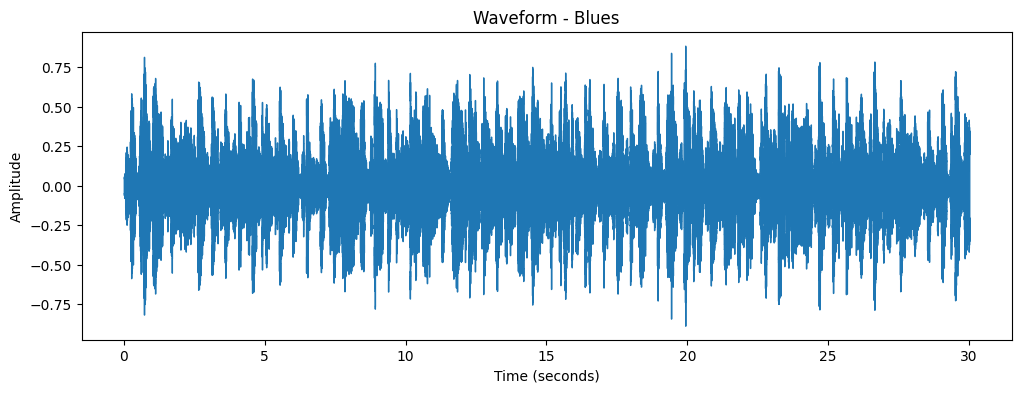

In [6]:
#plot of a raw .wav file
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform - Blues")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [7]:
#conversion of one file to mfcc and dimention check
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (20, 1293)


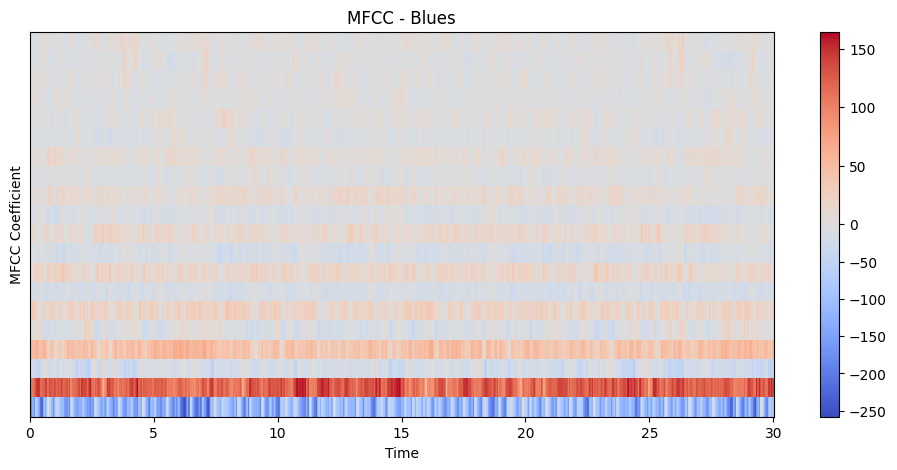

In [8]:
#plot of one mfcc file
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC - Blues")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficient")
plt.show()

In [19]:
# function to convert all files to mfcc
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=20
    )

    # Make every MFCC have exactly 1300 time frames
    target_frames = 1300

    if mfcc.shape[1] < target_frames:
        # Add zeros if too short
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, target_frames - mfcc.shape[1])),
            mode="constant"
        )
    else:
        # Cut extra frames if too long
        mfcc = mfcc[:, :target_frames]

    return mfcc

In [20]:
#funciton test
test_mfcc = extract_mfcc(file_path)

print(test_mfcc.shape)

(20, 1300)


In [21]:
#data Extraction and pre-processing
X = []
y = []

for genre in genres:
    
    genre_path = os.path.join(DATASET_PATH, genre)
    
    files = [
        f for f in os.listdir(genre_path)
        if f.endswith(".wav")
    ]
    
    for file in files:
        
        file_path = os.path.join(genre_path, file)
        
        mfcc = extract_mfcc(file_path)
        
        # Convert 2D MFCC into 1D feature vector
        features = mfcc.flatten()
        
        X.append(features)
        y.append(genre)

print("Number of samples:", len(X))
print("Number of labels:", len(y))

Number of samples: 500
Number of labels: 500


In [22]:
#inspection of sample size and feature size
print("Shape of first sample:", X[0].shape)
print("Shape of all samples:", np.array(X).shape)

Shape of first sample: (26000,)
Shape of all samples: (500, 26000)


In [23]:
#converting to numpy array
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 26000)
y shape: (500,)


In [25]:
#Splitting data into train and test sample(Ratio::80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [26]:
#standardization of data for effective results
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)


Training shape: (400, 26000)
Testing shape: (100, 26000)


In [27]:
#Classical Model Building
#Model 1:Logistic Regression:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.81


In [28]:
#Analysis of Model 1:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

       blues       0.93      0.70      0.80        20
   classical       0.95      0.95      0.95        20
      hiphop       0.82      0.45      0.58        20
       metal       0.67      1.00      0.80        20
         pop       0.79      0.95      0.86        20

    accuracy                           0.81       100
   macro avg       0.83      0.81      0.80       100
weighted avg       0.83      0.81      0.80       100



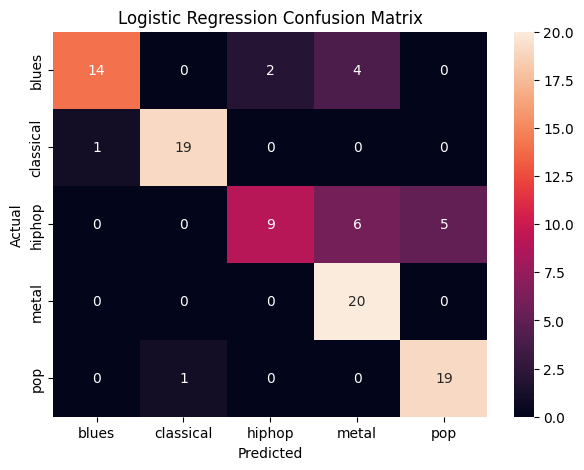

In [29]:
#confusion matrix for Model 1:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [31]:
#Model 2 :SVM:
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

SVM Accuracy: 0.81


In [32]:
#Model 2 Analysis:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

       blues       0.82      0.70      0.76        20
   classical       0.95      1.00      0.98        20
      hiphop       0.77      0.50      0.61        20
       metal       0.73      0.95      0.83        20
         pop       0.78      0.90      0.84        20

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.80       100
weighted avg       0.81      0.81      0.80       100



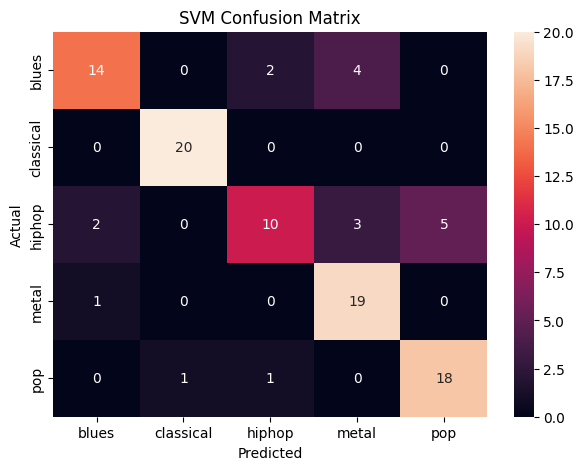

In [33]:
#Model 2 confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [34]:
#Model 3 :Random Forest:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.82


In [35]:
#Model 3 Analysis
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

       blues       0.82      0.70      0.76        20
   classical       0.95      1.00      0.98        20
      hiphop       0.77      0.50      0.61        20
       metal       0.73      0.95      0.83        20
         pop       0.78      0.90      0.84        20

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.80       100
weighted avg       0.81      0.81      0.80       100



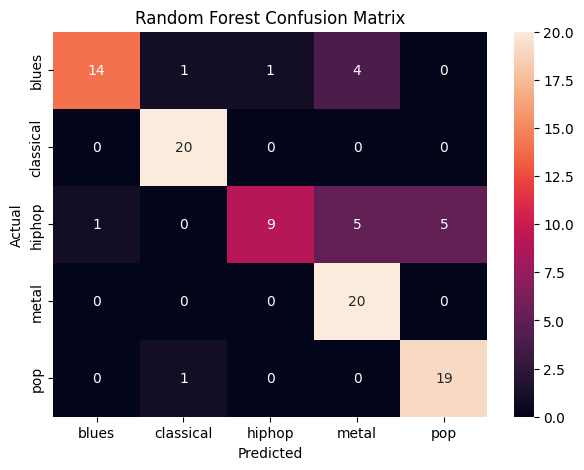

In [36]:
#Model 3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [37]:
#Model 4 :GDA
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)

print(
    "LDA Accuracy:",
    accuracy_score(y_test, y_pred_lda)
)

LDA Accuracy: 0.81


In [38]:
#Model 4 Analysis:
print(
    classification_report(
        y_test,
        y_pred_lda
    )
)

              precision    recall  f1-score   support

       blues       0.87      0.65      0.74        20
   classical       1.00      1.00      1.00        20
      hiphop       0.77      0.50      0.61        20
       metal       0.68      0.95      0.79        20
         pop       0.79      0.95      0.86        20

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.80       100
weighted avg       0.82      0.81      0.80       100



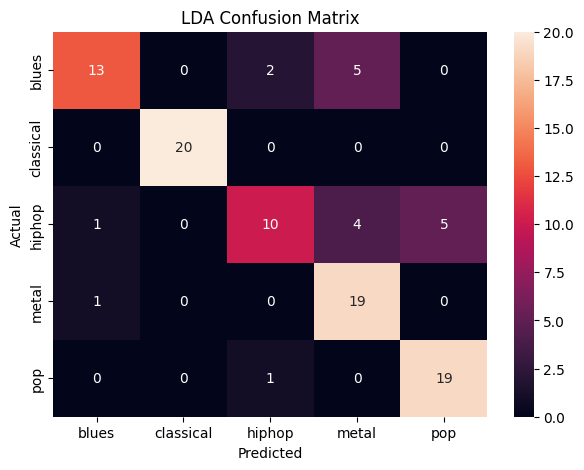

In [40]:
# LDA confusion Matrix
cm = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LDA Confusion Matrix")

plt.show()

In [41]:
 #PCA to get 50 features 
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Training shape:", X_train_pca.shape)
print("Testing shape:", X_test_pca.shape)

Training shape: (400, 50)
Testing shape: (100, 50)


In [49]:
#Implementing GDA:
import numpy as np

class GDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.priors = {}

        n_features = X.shape[1]

        # Shared covariance matrix
        self.covariance = np.zeros((n_features, n_features))

        for c in self.classes:

            # Get samples belonging to class c
            X_c = X[y == c]

            # Calculate mean vector
            self.means[c] = np.mean(X_c, axis=0)

            # Calculate class prior
            self.priors[c] = len(X_c) / len(X)

            # Add covariance contribution
            centered = X_c - self.means[c]
            self.covariance += centered.T @ centered

        # Shared covariance
        self.covariance /= len(X)

        # Small value added to diagonal for numerical stability
        self.covariance += 1e-6 * np.eye(n_features)

        # Calculate inverse covariance
        self.covariance_inv = np.linalg.inv(self.covariance)

        return self

    def predict(self, X):

        predictions = []

        for x in X:

            scores = {}

            for c in self.classes:

                mean = self.means[c]

                # Difference between sample and class mean
                diff = x - mean

                # GDA discriminant score
                score = (
                    -0.5 * diff.T @ self.covariance_inv @ diff
                    + np.log(self.priors[c])
                )

                scores[c] = score

            # Choose class with highest score
            predicted_class = max(scores, key=scores.get)

            predictions.append(predicted_class)

        return np.array(predictions)

In [50]:
#Building GDA Model and Training it
gda = GDA()

gda.fit(X_train_pca, y_train)

y_pred_gda = gda.predict(X_test_pca)

print("GDA Accuracy:", accuracy_score(y_test, y_pred_gda))

GDA Accuracy: 0.81


In [51]:
print(classification_report(
    y_test,
    y_pred_gda
))

              precision    recall  f1-score   support

       blues       0.87      0.65      0.74        20
   classical       0.95      1.00      0.98        20
      hiphop       0.83      0.50      0.62        20
       metal       0.68      0.95      0.79        20
         pop       0.79      0.95      0.86        20

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.80       100
weighted avg       0.82      0.81      0.80       100



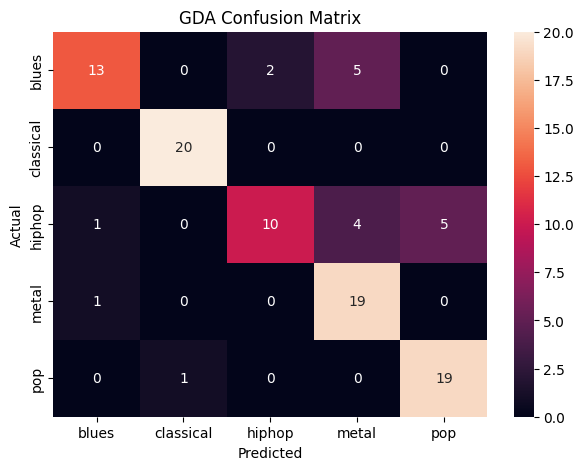

In [52]:
cm = confusion_matrix(y_test, y_pred_gda)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GDA Confusion Matrix")

plt.show()

In [53]:
#Logistic Regression with PCA
lr_pca = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = lr_pca.predict(X_test_pca)

print("PCA + Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr_pca))

PCA + Logistic Regression Accuracy: 0.85


In [54]:
print(classification_report(y_test, y_pred_lr_pca))

              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        20
   classical       1.00      1.00      1.00        20
      hiphop       0.73      0.55      0.63        20
       metal       0.79      0.95      0.86        20
         pop       0.83      0.95      0.88        20

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.84       100
weighted avg       0.85      0.85      0.84       100



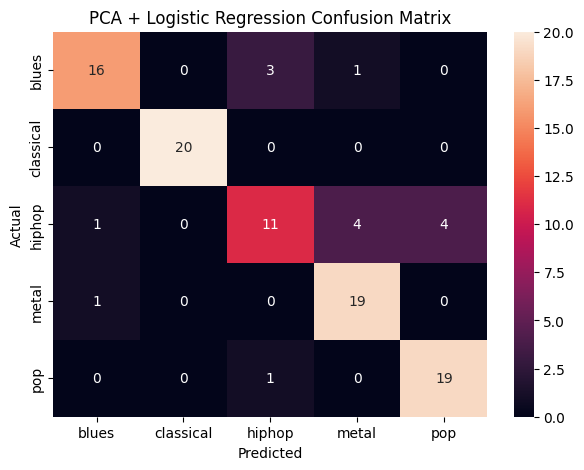

In [55]:
cm = confusion_matrix(y_test, y_pred_lr_pca)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCA + Logistic Regression Confusion Matrix")

plt.show()

In [56]:
#SVM with PCA
svm_pca = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_pca.fit(X_train_pca, y_train)

y_pred_svm_pca = svm_pca.predict(X_test_pca)

print("PCA + SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm_pca))

PCA + SVM Accuracy: 0.85


In [57]:
print(classification_report(y_test, y_pred_svm_pca))

              precision    recall  f1-score   support

       blues       0.85      0.85      0.85        20
   classical       1.00      1.00      1.00        20
      hiphop       0.91      0.50      0.65        20
       metal       0.72      0.90      0.80        20
         pop       0.83      1.00      0.91        20

    accuracy                           0.85       100
   macro avg       0.86      0.85      0.84       100
weighted avg       0.86      0.85      0.84       100



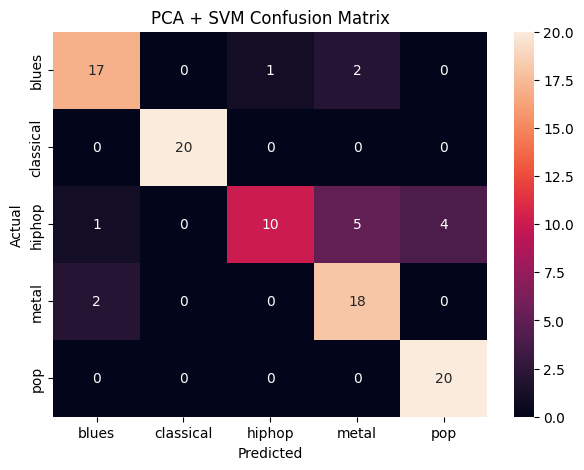

In [58]:
cm = confusion_matrix(y_test, y_pred_svm_pca)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCA + SVM Confusion Matrix")

plt.show()

In [59]:
#Random Forest with PCA
rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)

print("PCA + Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf_pca))

PCA + Random Forest Accuracy: 0.79


In [60]:
print(classification_report(y_test, y_pred_rf_pca))

              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        20
   classical       0.90      0.90      0.90        20
      hiphop       0.69      0.45      0.55        20
       metal       0.69      0.90      0.78        20
         pop       0.78      0.90      0.84        20

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.78       100
weighted avg       0.79      0.79      0.78       100



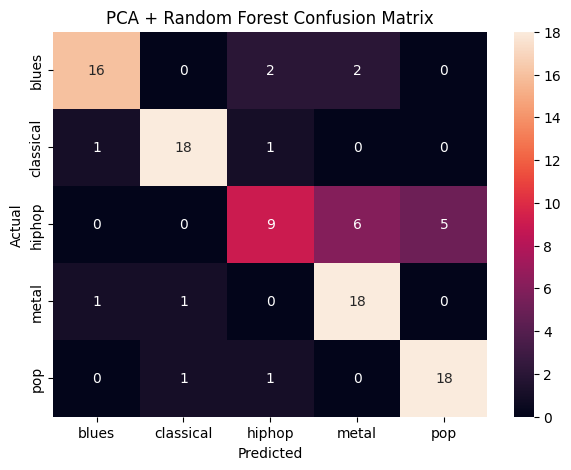

In [61]:
cm = confusion_matrix(y_test, y_pred_rf_pca)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=genres,
    yticklabels=genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCA + Random Forest Confusion Matrix")

plt.show()

In [62]:
#Comparisions between different models with PCA
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "GDA"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_pca),
        accuracy_score(y_test, y_pred_svm_pca),
        accuracy_score(y_test, y_pred_rf_pca),
        accuracy_score(y_test, y_pred_gda)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.85
1,SVM,0.85
2,Random Forest,0.79
3,GDA,0.81


In [63]:
#Comparision between models with and without PCA
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "GDA"
    ],
    "Original MFCC": [
        accuracy_lr,
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        np.nan
    ],
    "PCA (50)": [
        accuracy_score(y_test, y_pred_lr_pca),
        accuracy_score(y_test, y_pred_svm_pca),
        accuracy_score(y_test, y_pred_rf_pca),
        accuracy_score(y_test, y_pred_gda)
    ]
})

comparison

,Model,Original MFCC,PCA (50)
0,Logistic Regression,0.81,0.85
1,SVM,0.81,0.85
2,Random Forest,0.82,0.79
3,GDA,NaN,0.81


In [65]:
#Using GridSeacrchCV for Parameter Tuning:
from sklearn.model_selection import GridSearchCV


In [66]:
#Tuning Logistic Regression:
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train_pca, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("Best cross-validation accuracy:")
print(lr_grid.best_score_)

Best Logistic Regression parameters:
{'C': 0.01}
Best cross-validation accuracy:
0.8099999999999999


In [67]:
#Testing the best Parameter:
best_lr = lr_grid.best_estimator_

y_pred_lr_grid = best_lr.predict(X_test_pca)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_lr_grid))

Test Accuracy: 0.84


In [68]:
#Tuning SVM:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf"),
    svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train_pca, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("Best cross-validation accuracy:")
print(svm_grid.best_score_)

Best SVM parameters:
{'C': 10, 'gamma': 'scale'}
Best cross-validation accuracy:
0.8699999999999999


In [69]:
#Testing SVM:
best_svm = svm_grid.best_estimator_

y_pred_svm_grid = best_svm.predict(X_test_pca)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_svm_grid))

Test Accuracy: 0.85


In [70]:
#Tuning Random Forest:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_pca, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best cross-validation accuracy:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy:
0.8299999999999998


In [71]:
#Testing it:
best_rf = rf_grid.best_estimator_

y_pred_rf_grid = best_rf.predict(X_test_pca)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_rf_grid))

Test Accuracy: 0.81


In [72]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "GDA"
    ],
    
    "PCA Accuracy": [
        accuracy_score(y_test, y_pred_lr_grid),
        accuracy_score(y_test, y_pred_svm_grid),
        accuracy_score(y_test, y_pred_rf_grid),
        accuracy_score(y_test, y_pred_gda)
    ]
})

final_results

,Model,PCA Accuracy
0,Logistic Regression,0.84
1,SVM,0.85
2,Random Forest,0.81
3,GDA,0.81
